# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [ ]:
#packages nécessaires à installer avant import : numpy pandas scipy matplotlib statsmodels seaborn

import importlib
import functions
importlib.reload(functions)

from functions import (  # noqa: E402
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions_univ,
    comparer_distributions,
    cdf_t_univ_norm,
    plot_distributions_univ_norm,
    extract_month_data
)

#import SBCK # noqa: E402
import pandas as pd

## Implémentation CDF-t univariée (température)

### Correction CMIP6 sur les observations

On corrige pour chaque mois. On compare les distributions en représentant graphiquement les densités et en réalisant quelques statistiques descriptives.

<Figure size 1200x600 with 0 Axes>

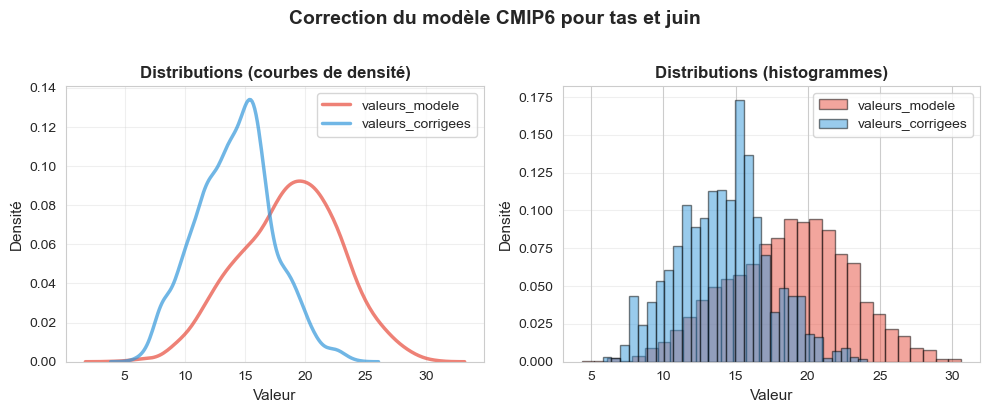

  Statistique  valeurs_modele  valeurs_corrigees
0     Moyenne          18.700             14.154
1     Médiane          18.922             14.275
2  Écart-type           4.214              3.162
3    Variance          17.762              9.997
4     Minimum           4.353              5.800
5     Maximum          30.613             24.113
6    Q1 (25%)          15.782             11.890
7    Q3 (75%)          21.671             16.160
8     Étendue          26.260             18.314


<Figure size 1200x600 with 0 Axes>

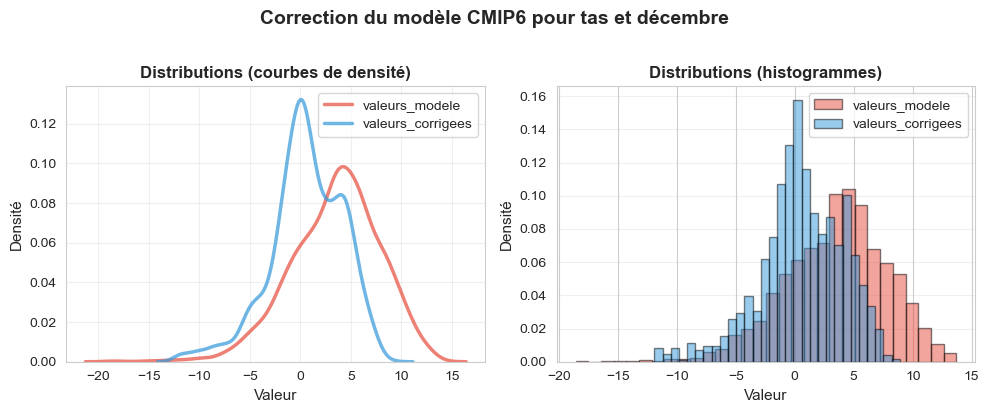

  Statistique  valeurs_modele  valeurs_corrigees
0     Moyenne           3.479              0.588
1     Médiane           3.852              0.571
2  Écart-type           4.363              3.586
3    Variance          19.035             12.860
4     Minimum         -18.579            -11.900
5     Maximum          13.698              8.907
6    Q1 (25%)           0.658             -1.313
7    Q3 (75%)           6.452              3.244
8     Étendue          32.277             20.807


In [20]:
mois_a_afficher = [6, 12]  

for i in range (1,13): #on itère sur tous les mois

    #Sélection mois et variable
    CMIP6_hist = csv_to_pd_univ("data\CMIP6_historical.csv", i, "tas", years = (1982,2014))
    CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", i, "tas", years= (2015,2100))
    obs_hist = csv_to_pd_univ("data/obs.csv", i, "tas", years = (1982,2014))

    #Correction des valeurs futures du modèle par CDF-t
    resultat = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur)

    #Représentation graphique
    if i in mois_a_afficher:
        plot_distributions_univ(resultat,"CMIP6", i, "tas")
        print(comparer_distributions(resultat))

On vérifie en utilisant comme estimations futures les estimations passées pour reconstruire les observations passées.

<Figure size 1200x600 with 0 Axes>

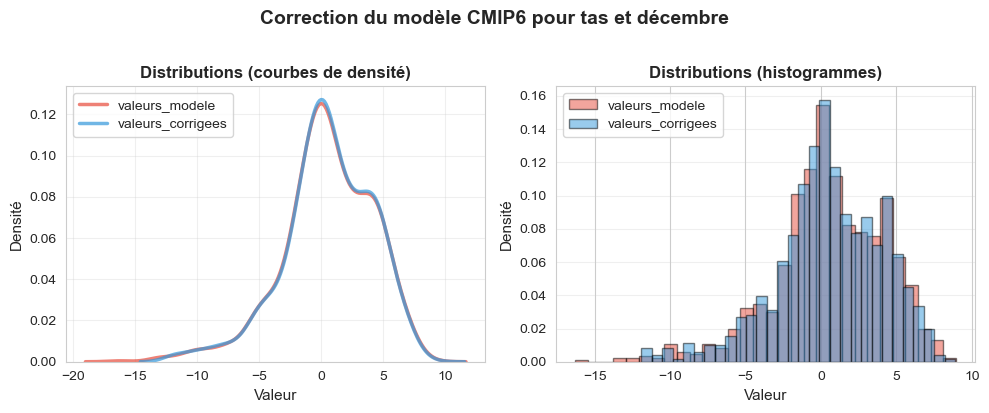

  Statistique  valeurs_modele  valeurs_corrigees
0     Moyenne           0.552              0.592
1     Médiane           0.530              0.571
2  Écart-type           3.675              3.587
3    Variance          13.504             12.869
4     Minimum         -16.273            -11.900
5     Maximum           8.956              8.907
6    Q1 (25%)          -1.377             -1.313
7    Q3 (75%)           3.273              3.244
8     Étendue          25.229             20.807


In [21]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ("data/CMIP6_historical.csv", 12, "tas", years= (1982,2014))
obs_hist = csv_to_pd_univ("data/obs.csv", i, "tas", years= (1982,2014))

#Correction des valeurs futures du modèle par CDF-t
resultat = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur)

#Représentation graphique
plot_distributions_univ(resultat,"CMIP6", 12, "tas")
print(comparer_distributions(resultat))

On corrige cette fois dans le cas gaussien. On suppose que les distributions du modèle (passées et futures) et que les observations passées sont gaussiennes. Les observations futures sont alors aussi gaussienne et on peut estimer le paramètre de la loi à partir des paramètres des distributions connues.

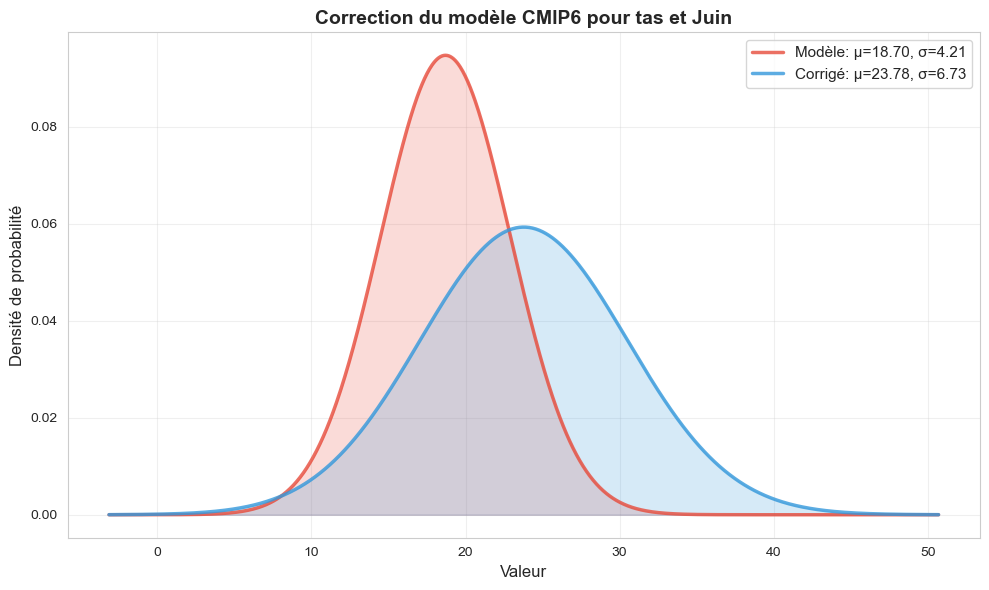

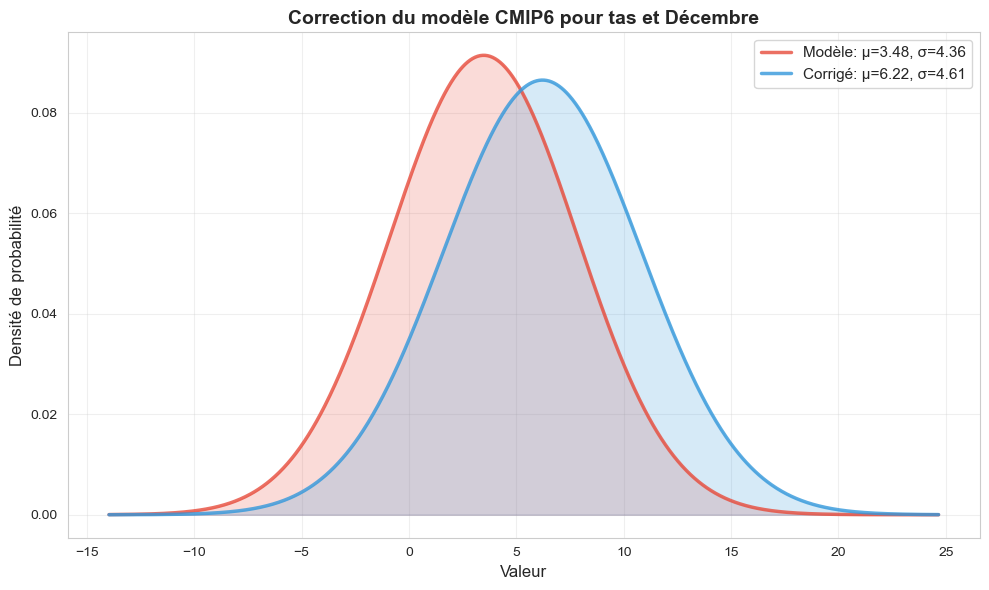

In [22]:
mois_a_afficher = [6, 12]  

for i in range (1,13): #on itère sur tous les mois

    #Sélection mois et variable
    CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", i, "tas", years = (1982,2014))
    CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", i, "tas", years= (2015,2100))
    obs_hist = csv_to_pd_univ("data/obs.csv", i, "tas" , years = (1982,2014))

    #Correction des valeurs futures du modèle par CDF-t
    resultat = cdf_t_univ_norm(CMIP6_hist,obs_hist,CMIP6_futur)

    #Représentation graphique
    if i in mois_a_afficher:
        plot_distributions_univ_norm(resultat[0],resultat[1],"CMIP6", i, "tas")



## Implémentation CDF-t multivariée

In [ ]:
"""
month = 1

common_columns = ['tas', 'uas', 'vas', 'rsds', 'rlds']

# Extraire les données pour le mois choisi
Y0 = extract_month_data("data/obs.csv", month, common_columns, years = (1982,2014))  # Observations
X0 = extract_month_data("data/CMIP6_historical.csv", month, common_columns, years = (1982, 2014) )  # Modèle passé
X1 = extract_month_data("data/CMIP6_ssp585.csv", month, common_columns, years = (2015,2100))  # Modèle futur


# Appliquer la correction MBCn
mbc = SBCK.MBCn()

# Calibration avec les 3 datasets
mbc.fit(Y0, X0, X1)

# Correction des valeurs futures
X1_corrected, _ = mbc.predict(X1, X0)

# Sauvegarder les résultats
df_corrected = pd.DataFrame(X1_corrected, columns=common_columns)

output_path = f'data/CMIP6_ssp585_corrected_month_{month}.csv'
df_corrected.to_csv(output_path, sep=';', index=False)
"""

Données extraites de data/obs.csv: 8184 lignes, 5 variables pour le mois 1 (1982-2014)
Données extraites de data/CMIP6_historical.csv: 1023 lignes, 5 variables pour le mois 1 (1982-2014)
Données extraites de data/CMIP6_ssp585.csv: 2666 lignes, 5 variables pour le mois 1 (2015-2100)
